In [1]:
import pandas as pd
from functools import reduce

In [ ]:
import re
import pandas as pd

def rename_result_columns(df: pd.DataFrame) -> pd.DataFrame:
    SRC = {
        "Объем кредитования РК": "kz_loans",
        "Индексы потребительских цен г-г": "kz_cpi_yoy",
        "Индексы государственных ценных бумаг": "kz_gov_bond_idx",
        "Индекс цен корпоративных облигаций": "kz_corp_bond_idx",
        "ВВП на душу населения": "kz_gdp_pc",
        "Базовая ставка РК": "kz_base_rate",
        "Инфляция и ключевая ставка Банка России": "ru_key_rate",
        "Индекс потребительских цен": "ru_cpi",
        "Бескупонная доходность ОФЗ": "ru_ofz_zero_yield",
        "Безработица": "ru_labor",
        "RUONIA(ставка овернайта)": "ru_ruonia",
    }

    MET = {
        "Total": "total",
        "loans to business": "biz",
        "loans to Individuals": "hh",
        "national currency": "kzt",
        "foreign currency": "fx",
        "small business": "sme_s",
        "medium business": "sme_m",
        "large business": "corp_l",
        "mortgage loans": "mortgage",
        "consumer loans": "consumer",
        "others": "other",

        "dec_dec": "yoy_dec",
        "jan_dec": "yoy_avg",

        "rate_pct": "pct",
        "key_rate": "pct",
        "inflation": "pct",

        "OPEN": "open",
        "HIGH": "high",
        "LOW": "low",
        "CLOSE": "close",
        "VALUE": "value",
        "VOLUME": "volume",
        "YIELD": "yield",
        "DURATION": "duration",

        "ruo": "pct",
        "vol": "volume",
    }

    def slug(s: str) -> str:
        s = str(s).strip()
        s = s.replace("\u00A0", " ")
        s = re.sub(r"\s+", "_", s)
        s = re.sub(r"[^0-9a-zA-Z_\.]+", "", s)
        return s.lower()

    def map_one(col: str) -> str:
        if col == "date":
            return "date"

        if "__" in col:
            src, rest = col.split("__", 1)
            src_en = SRC.get(src.strip(), slug(src))

            parts = [p.strip() for p in rest.split("__")]
            parts = [MET.get(p, slug(p)) for p in parts]

            return src_en + "_" + "_".join(parts)

        return MET.get(col.strip(), slug(col))

    out = df.copy()
    new_cols = [map_one(c) for c in out.columns]

    seen = {}
    fixed = []
    for c in new_cols:
        k = c
        if k not in seen:
            seen[k] = 1
            fixed.append(k)
        else:
            seen[k] += 1
            fixed.append(f"{k}_{seen[k]}")

    out.columns = fixed
    return out


In [ ]:
import pandas as pd
from functools import reduce

import read_functions as rf

series = {}
for rel_path, func in rf.dict_func.items():
    df = func(rel_path).copy()

    if "date" not in df.columns:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index().rename(columns={"index": "date"})
        else:
            raise ValueError(f"No 'date' column: {rel_path}")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    prefix = rel_path.split("/")[-1].replace(".csv", "").strip()
    rename_map = {c: f"{prefix}__{c}" for c in df.columns if c != "date"}
    df = df.rename(columns=rename_map)

    series[rel_path] = df

all_dates = pd.concat([df["date"] for df in series.values()]).unique()
max_date = pd.to_datetime(all_dates).max()
calendar = pd.DataFrame({"date": pd.date_range(start="2013-01-01", end=max_date, freq="D")})

result = calendar.copy()
for rel_path, df in series.items():
    result = pd.merge(result, df, on="date", how="left")

for col in result.columns:
    if col != "date":
        result[col] = result[col].ffill() 

result = result.sort_values("date").reset_index(drop=True)

print(result.shape)
print(result.head(10))
print(result.tail(10))


(4777, 106)
        date  Объем кредитования РК__Total  \
0 2013-01-01                           NaN   
1 2013-01-02                           NaN   
2 2013-01-03                           NaN   
3 2013-01-04                           NaN   
4 2013-01-05                           NaN   
5 2013-01-06                           NaN   
6 2013-01-07                           NaN   
7 2013-01-08                           NaN   
8 2013-01-09                           NaN   
9 2013-01-10                           NaN   

   Объем кредитования РК__loans to business  \
0                                       NaN   
1                                       NaN   
2                                       NaN   
3                                       NaN   
4                                       NaN   
5                                       NaN   
6                                       NaN   
7                                       NaN   
8                                       NaN   
9          

In [12]:
result.to_csv("all_metrics.csv")

In [15]:
result.columns.tolist()

['date',
 'Объем кредитования РК__Total',
 'Объем кредитования РК__loans to business',
 'Объем кредитования РК__national currency',
 'Объем кредитования РК__foreign currency',
 'Объем кредитования РК__small business',
 'Объем кредитования РК__medium business',
 'Объем кредитования РК__large business',
 'Объем кредитования РК__loans to Individuals',
 'Объем кредитования РК__national currency',
 'Объем кредитования РК__foreign currency',
 'Объем кредитования РК__mortgage loans',
 'Объем кредитования РК__consumer loans',
 'Объем кредитования РК__others',
 'Индексы потребительских цен г-г__dec_dec__alcohol_and_tobacco',
 'Индексы потребительских цен г-г__dec_dec__clothing_and_footwear',
 'Индексы потребительских цен г-г__dec_dec__communication',
 'Индексы потребительских цен г-г__dec_dec__education',
 'Индексы потребительских цен г-г__dec_dec__food',
 'Индексы потребительских цен г-г__dec_dec__food_products',
 'Индексы потребительских цен г-г__dec_dec__goods_and_services',
 'Индексы потреб

In [23]:
result2 = rename_result_columns(result)
result2.columns.tolist()

['date',
 'kz_loans_total',
 'kz_loans_biz',
 'kz_loans_kzt',
 'kz_loans_fx',
 'kz_loans_sme_s',
 'kz_loans_sme_m',
 'kz_loans_corp_l',
 'kz_loans_hh',
 'kz_loans_kzt_2',
 'kz_loans_fx_2',
 'kz_loans_mortgage',
 'kz_loans_consumer',
 'kz_loans_other',
 'kz_cpi_yoy_yoy_dec_alcohol_and_tobacco',
 'kz_cpi_yoy_yoy_dec_clothing_and_footwear',
 'kz_cpi_yoy_yoy_dec_communication',
 'kz_cpi_yoy_yoy_dec_education',
 'kz_cpi_yoy_yoy_dec_food',
 'kz_cpi_yoy_yoy_dec_food_products',
 'kz_cpi_yoy_yoy_dec_goods_and_services',
 'kz_cpi_yoy_yoy_dec_healthcare',
 'kz_cpi_yoy_yoy_dec_household_goods',
 'kz_cpi_yoy_yoy_dec_housing_services_and_other_fuels',
 'kz_cpi_yoy_yoy_dec_miscellaneous_goods_and_services',
 'kz_cpi_yoy_yoy_dec_non_alcoholic_beverages',
 'kz_cpi_yoy_yoy_dec_non_food_goods',
 'kz_cpi_yoy_yoy_dec_paid_services',
 'kz_cpi_yoy_yoy_dec_recreation_and_culture',
 'kz_cpi_yoy_yoy_dec_restaurants_and_hotels',
 'kz_cpi_yoy_yoy_dec_transport',
 'kz_cpi_yoy_yoy_avg_alcohol_and_tobacco',
 'kz_cpi

In [26]:
import pandas as pd

df = result2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

W = df.resample("W-FRI").last()

W_num = W.apply(pd.to_numeric, errors="coerce")
X = W_num.diff()


In [29]:
print("X shape:", X.shape)
print("columns sample:", X.columns[:10].tolist())

ofz_cols = [c for c in X.columns if "ru_ofz_zero_yield_period_" in c]
other_cols = [c for c in X.columns if c not in ofz_cols]

print("ofz_cols:", len(ofz_cols))
print("other_cols:", len(other_cols))
print("ofz example:", ofz_cols[:5])


X shape: (683, 105)
columns sample: ['kz_loans_total', 'kz_loans_biz', 'kz_loans_kzt', 'kz_loans_fx', 'kz_loans_sme_s', 'kz_loans_sme_m', 'kz_loans_corp_l', 'kz_loans_hh', 'kz_loans_kzt_2', 'kz_loans_fx_2']
ofz_cols: 11
other_cols: 94
ofz example: ['ru_ofz_zero_yield_period_0.25', 'ru_ofz_zero_yield_period_0.5', 'ru_ofz_zero_yield_period_0.75', 'ru_ofz_zero_yield_period_1.0', 'ru_ofz_zero_yield_period_2.0']


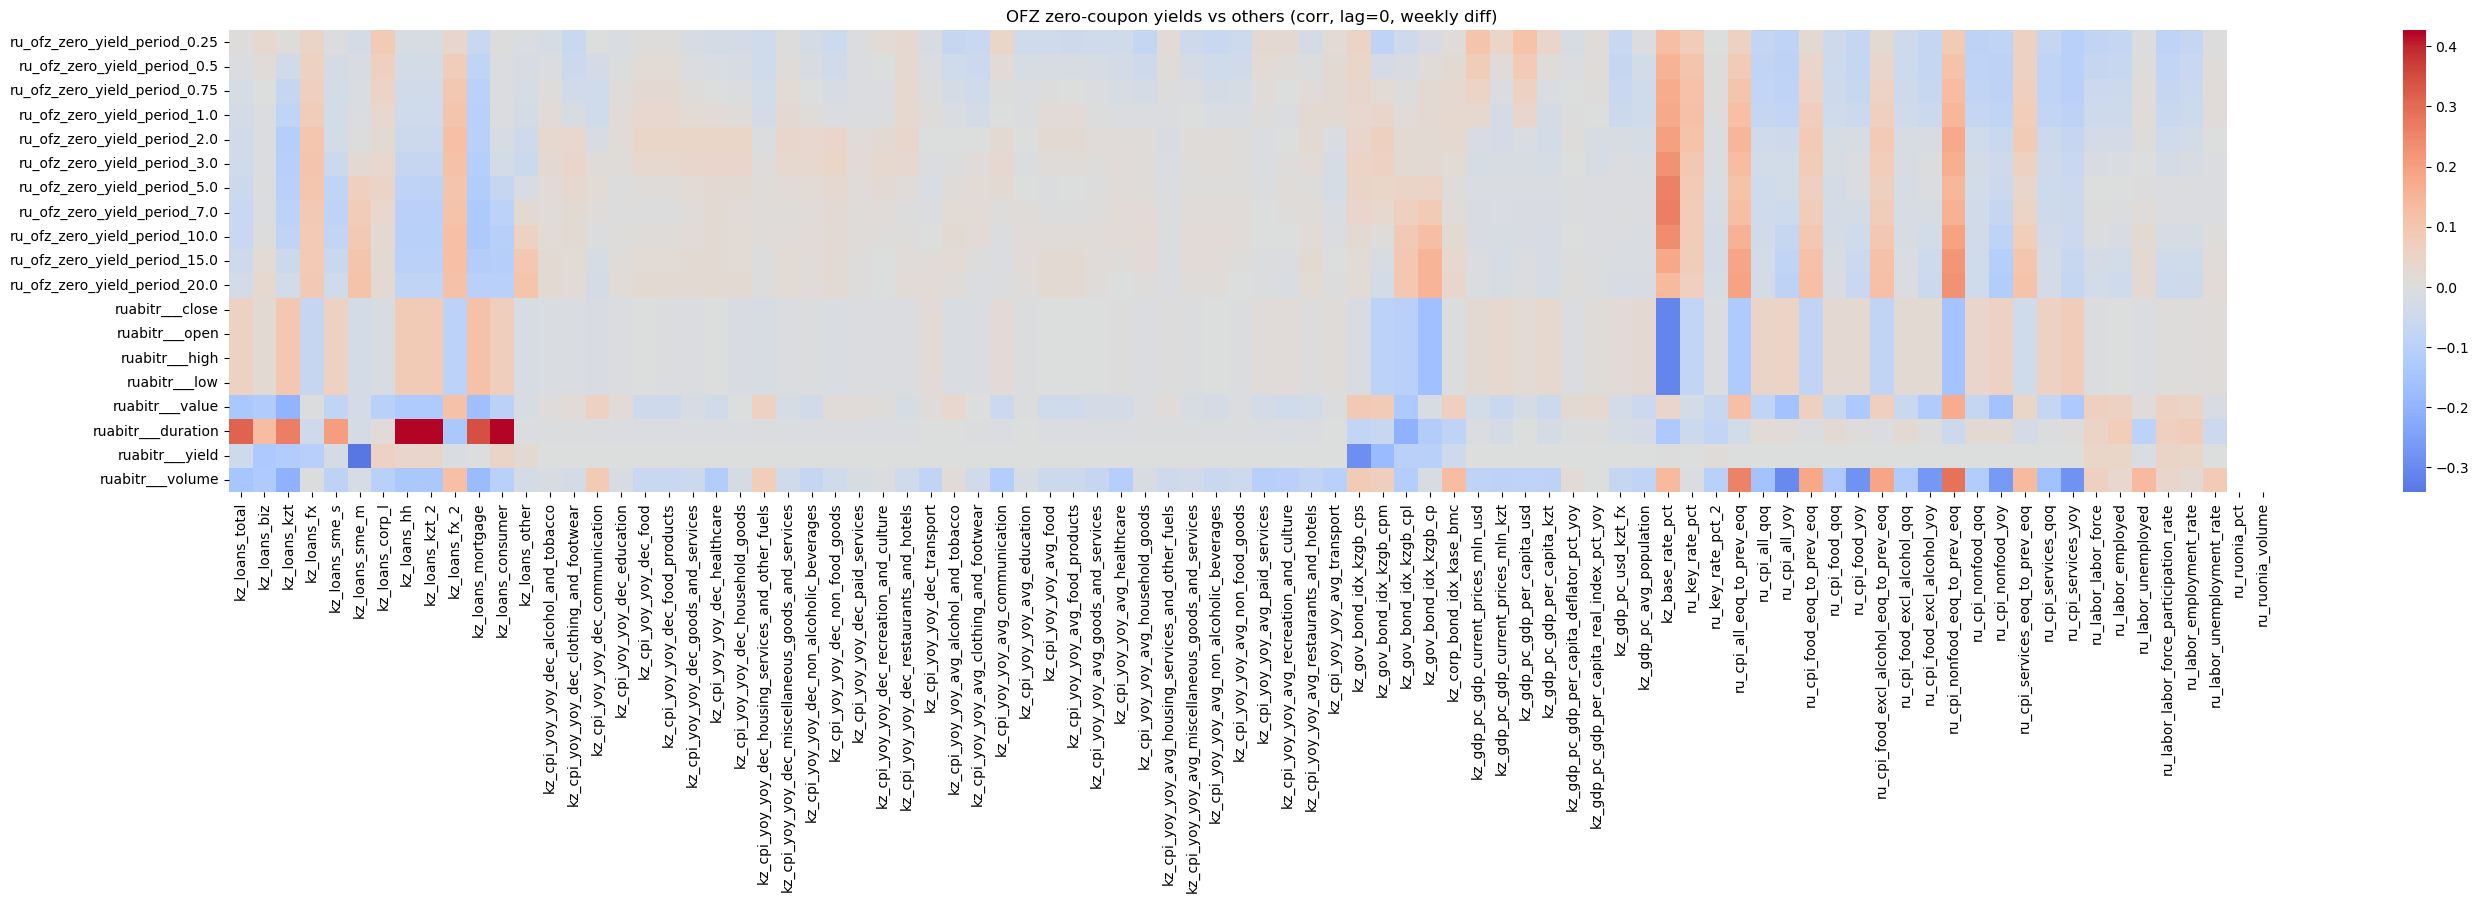

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

ofz_cols = [c for c in X.columns if (c.startswith("ru_ofz_zero_yield_period_") or c.startswith("ruabitr_"))]
other_cols = [c for c in X.columns if c not in ofz_cols]

corr = X[ofz_cols + other_cols].corr()

block = corr.loc[ofz_cols, other_cols]

plt.figure(figsize=(33, 6))
sns.heatmap(block, cmap="coolwarm", center=0)
plt.title("OFZ zero-coupon yields vs others (corr, lag=0, weekly diff)")
plt.show()


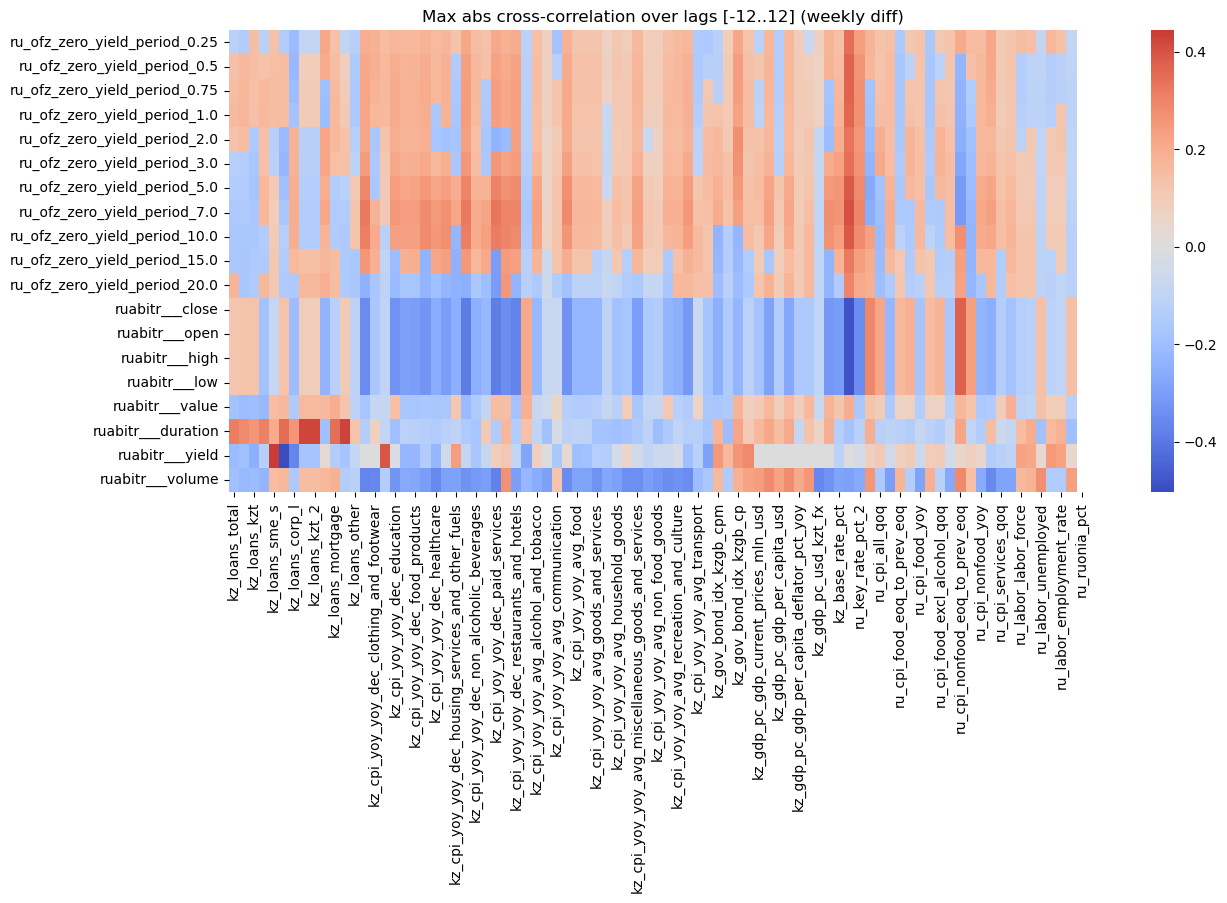

In [37]:
from statsmodels.tsa.stattools import ccf

def max_abs_xcorr(x, y, max_lag=12):
    z = pd.concat([x, y], axis=1).dropna()
    if len(z) < max_lag + 5:
        return np.nan, np.nan
    a = z.iloc[:, 0].to_numpy()
    b = z.iloc[:, 1].to_numpy()

    c_pos = ccf(a, b, adjusted=False)[:max_lag+1]
    c_neg = ccf(b, a, adjusted=False)[:max_lag+1]

    lags = np.arange(-max_lag, max_lag+1)
    vals = np.r_[c_neg[:0:-1], c_pos]
    i = np.nanargmax(np.abs(vals))
    return float(vals[i]), int(lags[i])

ofz = X[ofz_cols]
others = X[other_cols]

M = pd.DataFrame(index=ofz_cols, columns=other_cols, dtype=float)
L = pd.DataFrame(index=ofz_cols, columns=other_cols, dtype=float)

for oc in ofz_cols:
    for c in other_cols:
        m, lag = max_abs_xcorr(ofz[oc], others[c], max_lag=12)
        M.loc[oc, c] = m
        L.loc[oc, c] = lag

plt.figure(figsize=(14, 6))
sns.heatmap(M, cmap="coolwarm", center=0)
plt.title("Max abs cross-correlation over lags [-12..12] (weekly diff)")
plt.show()


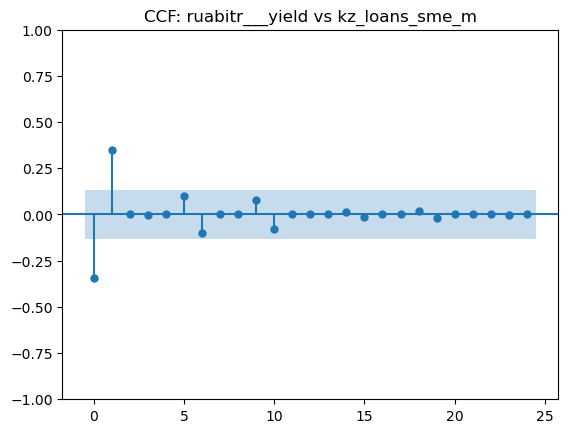

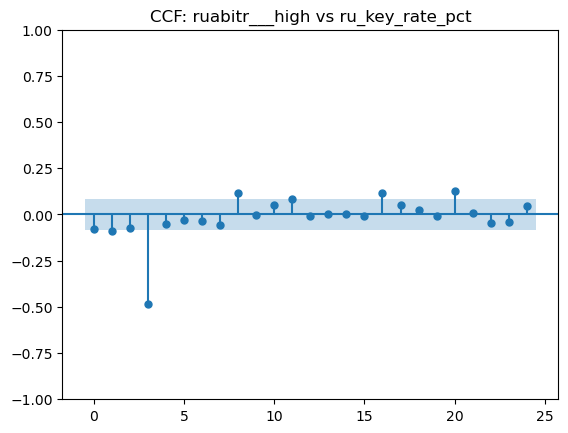

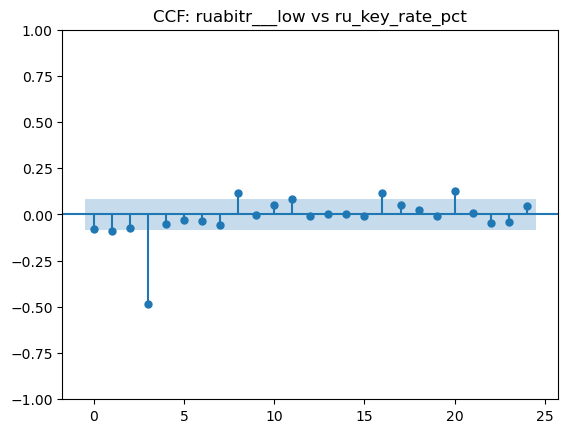

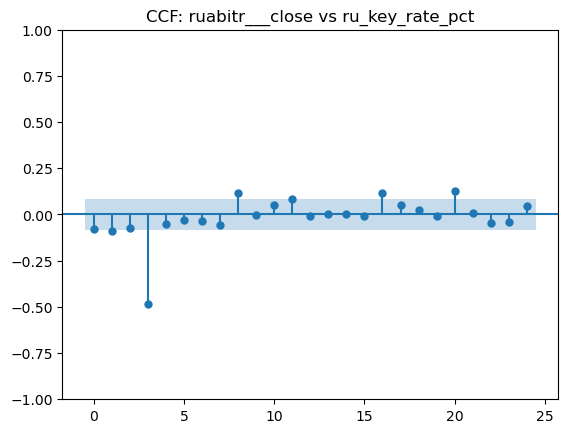

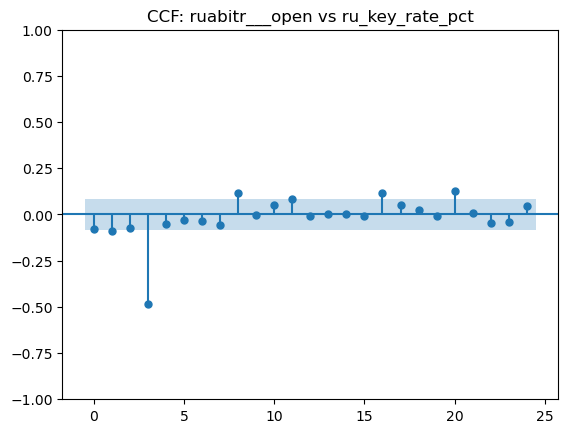

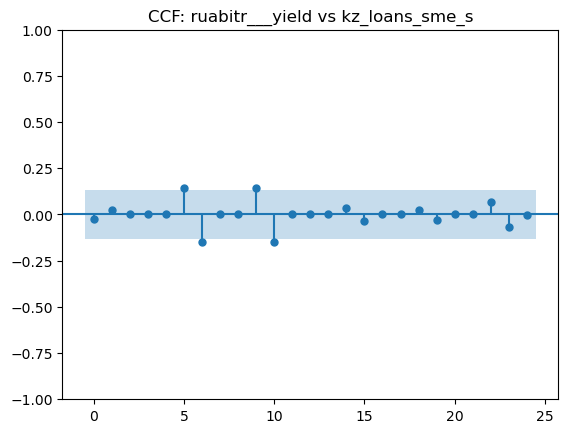

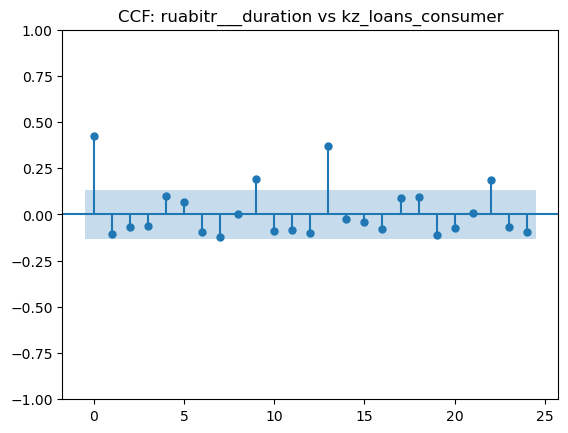

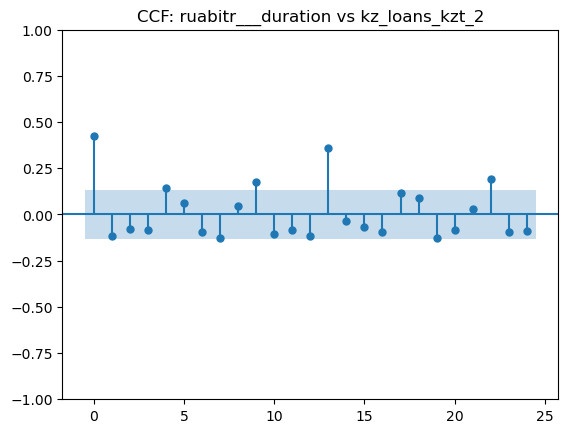

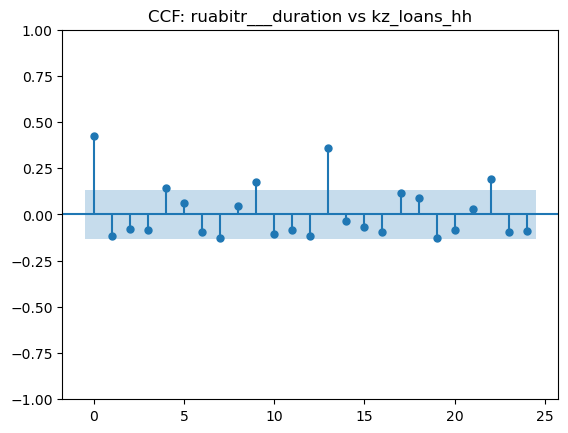

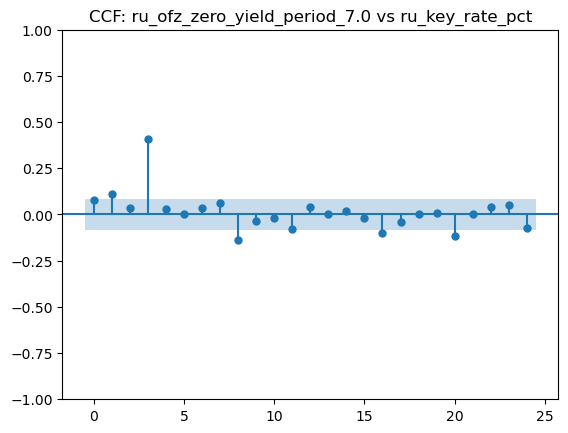

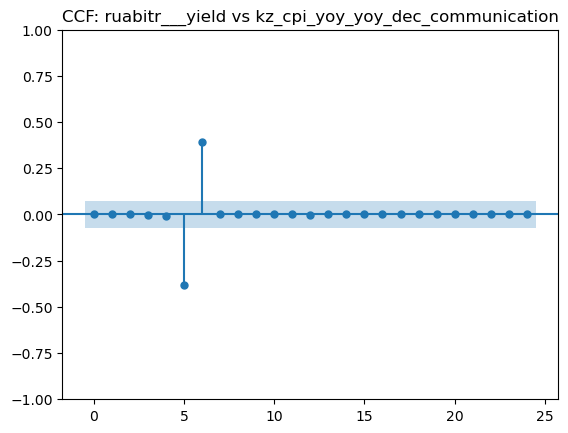

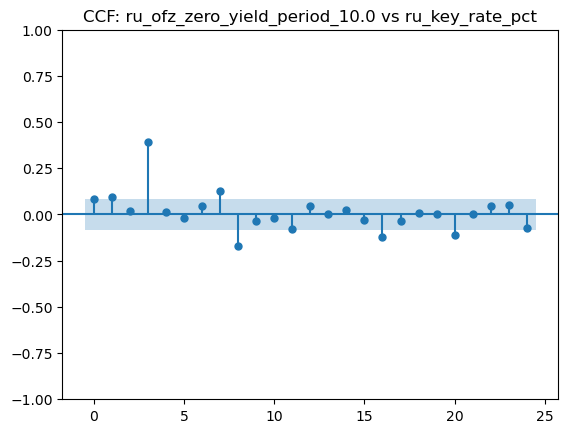

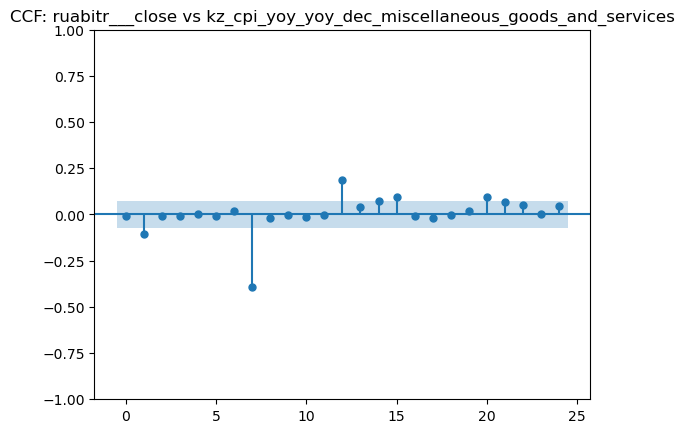

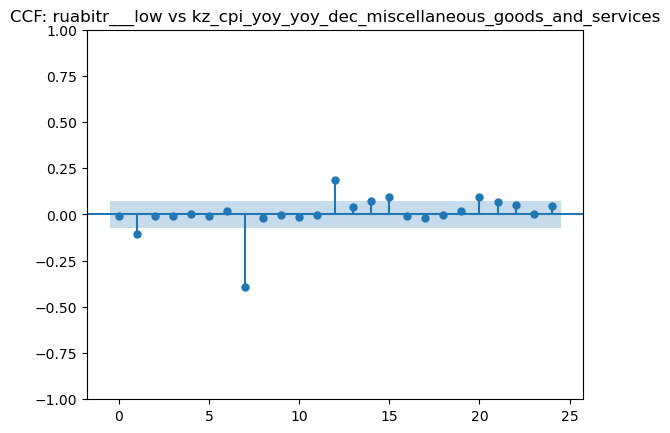

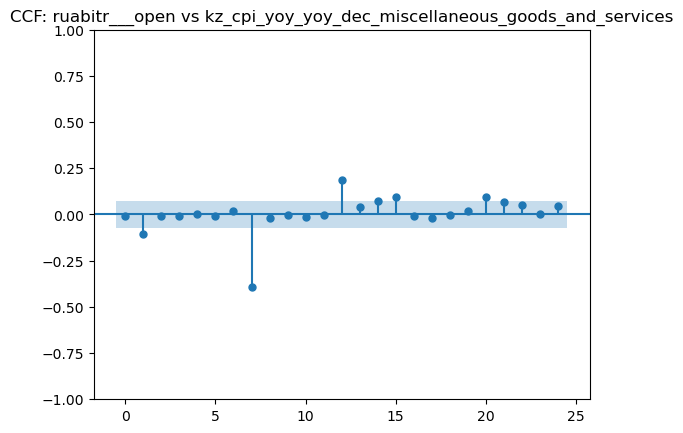

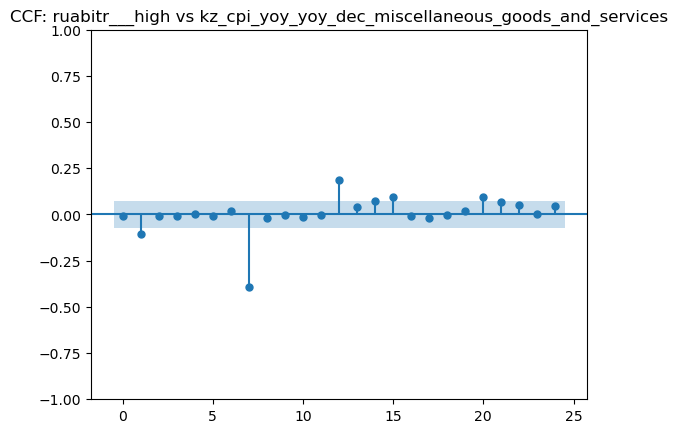

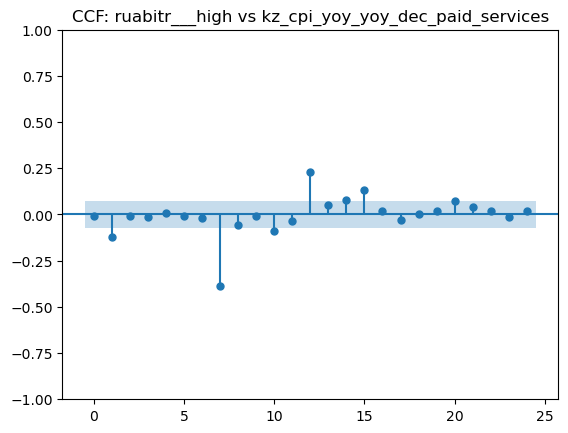

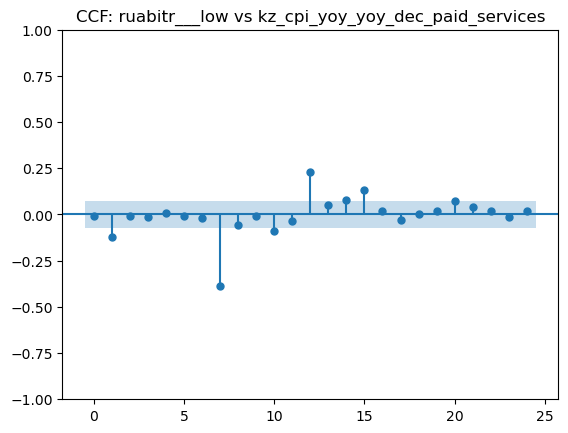

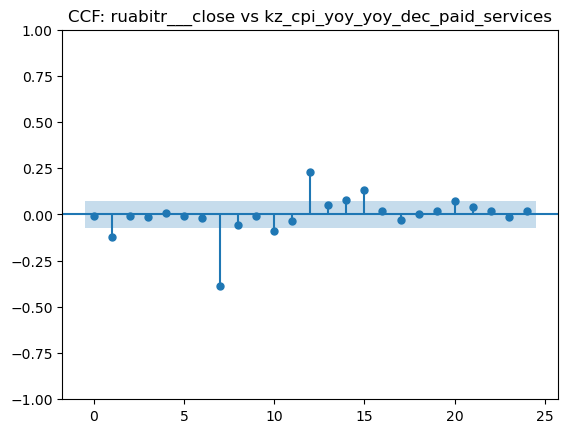

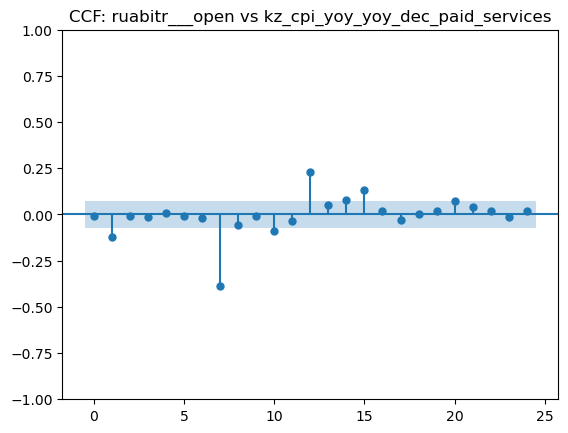

In [38]:
from statsmodels.graphics.tsaplots import plot_ccf
import matplotlib.pyplot as plt

top = (M.abs().stack().sort_values(ascending=False).head(20))
pairs = list(top.index)

for ofz_c, other_c in pairs:
    z = pd.concat([X[ofz_c], X[other_c]], axis=1).dropna()
    fig = plot_ccf(z[ofz_c], z[other_c], lags=24)
    plt.title(f"CCF: {ofz_c} vs {other_c}")
    plt.show()
